In [57]:
# Notebook to calculate weighted average insolation for single family homes in US

In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [59]:
# Load agents, solar resource
agents = pd.read_pickle("../data/agent_df_base_res_national_updated_wholesale_prices.pkl")
solar = pd.read_csv("../data/solar_resource.csv")

In [60]:
# Subset agents to only single family
agents_sf = (
    agents[
        (agents['owner_occupancy_status'] == 1) &
        (agents['crb_model'].isin(['Single-Family Attached', 'Single-Family Detached']))
    ]
)

agents_solar = (
    agents_sf
    .merge(solar, on = ['tilt', 'azimuth', 'solar_re_9809_gid'])
)

# Convert CF values to numpy arrays
def parse_pg_array(arr_str):
    return np.array(arr_str.strip("{}").split(","), dtype=float) / 1e6
agents_solar["cf_array"] = agents_solar["cf"].apply(parse_pg_array)

# Take annual mean
agents_solar["mean_cf"] = agents_solar["cf_array"].apply(lambda arr: arr.mean())


In [61]:
# Take weighted average with customers in bin as the weights
weighted_mean_cf = np.average(
    agents_solar["mean_cf"],
    weights=agents_solar["customers_in_bin_initial"]
)*24

# Calculate weighted mean for Phoenix, AZ
weighted_mean_cf_phoenix = np.average(
    agents_solar[agents_solar['county_id'] == "1763"]['mean_cf'],
    weights=agents_solar[agents_solar['county_id'] == "1763"]["customers_in_bin_initial"]
)*24

# Calculate weighted mean for Portland, ME
weighted_mean_cf_portland = np.average(
    agents_solar[agents_solar['county_id'] == "1707"]['mean_cf'],
    weights=agents_solar[agents_solar['county_id'] == "1707"]["customers_in_bin_initial"]
)*24

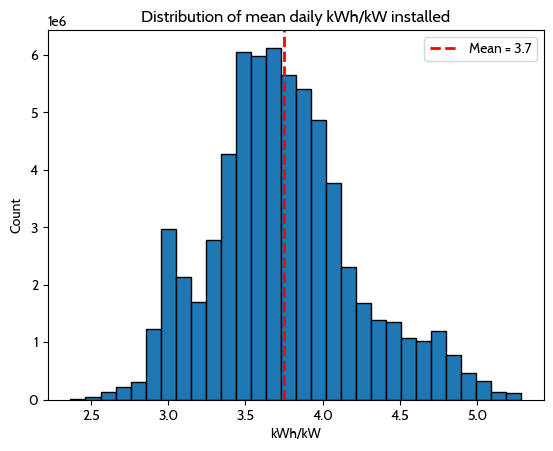

In [62]:
plt.hist(
    agents_solar["mean_cf"]*24,
    bins=30,
    weights=agents_solar["customers_in_bin_initial"],
    edgecolor="k"
)
plt.axvline(weighted_mean_cf, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {weighted_mean_cf:.1f}")

plt.xlabel("kWh/kW")
plt.ylabel("Count")
plt.title("Distribution of mean daily kWh/kW installed")
plt.legend()
plt.show()

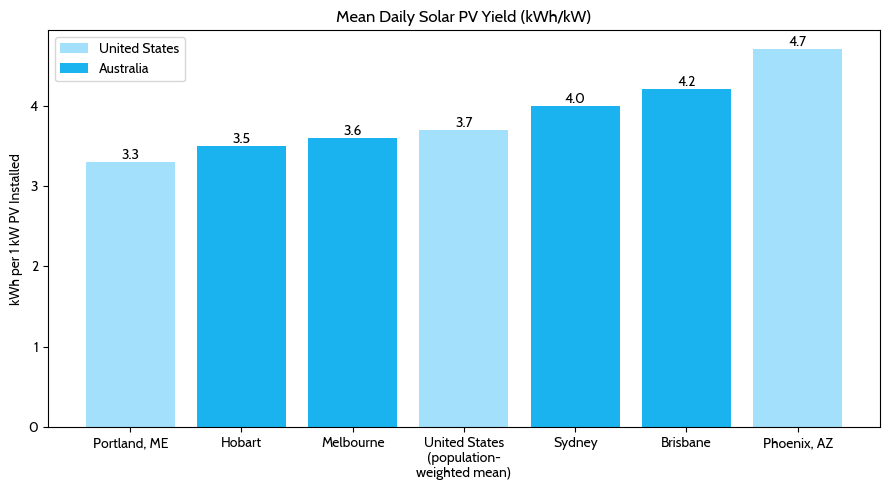

In [78]:
# ----- Input data (daily kWh per 1 kW installed) -----
data = [
    ("Alice Springs", 5.0),
    ("Darwin",        4.4),
    ("Perth",         4.4),
    ("Canberra",      4.3),
    ("Cairns",        4.2),
    ("Adelaide",      4.2),
    ("Brisbane",      4.2),
    ("Sydney",        4.0),
    ("Melbourne",     3.6),
    ("Hobart",        3.5),
]

df = pd.DataFrame(data, columns=["location", "daily_kwh_per_kw"])

# Add a US row, a Phoenix, AZ row, and a Portland, ME row
us_daily_kwh = round(weighted_mean_cf, 1)
phoenix_daily_kwh = round(weighted_mean_cf_phoenix, 1)
portland_daily_kwh = round(weighted_mean_cf_portland, 1)

df = pd.concat([df, pd.DataFrame([("United States\n(population-\nweighted mean)", us_daily_kwh),
                                  ("Portland, ME", portland_daily_kwh),
                                  ("Phoenix, AZ", phoenix_daily_kwh)
                                  ], columns=df.columns)], ignore_index=True)

# Limit
df_limited = df[df['location'].isin(['Portland, ME','Phoenix, AZ', 'United States\n(population-\nweighted mean)', 'Brisbane', 'Melbourne', 'Sydney', 'Hobart'])]

# Sort for a nicer chart
df_limited = df_limited.sort_values("daily_kwh_per_kw", ascending=True)

# ----- Plot -----
plt.rcParams["font.family"] = "Cabin"

# Define color scheme
us_color = "#a2e0fc"
au_color = "#1bb3ef"

# Build color list: default = #1bb3ef, override US = #a2e0fc
highlight = ['Portland, ME', 'Phoenix, AZ', 'United States\n(population-\nweighted mean)']
colors = [
    "#a2e0fc" if loc in highlight else "#1bb3ef"
    for loc in df_limited["location"]
]

plt.figure(figsize=(9, 5))
plt.bar(df_limited["location"], df_limited["daily_kwh_per_kw"], edgecolor=None, color=colors)
plt.xticks(ha="center")
plt.ylabel("kWh per 1 kW PV Installed")
plt.title("Mean Daily Solar PV Yield (kWh/kW)")
# Optional: annotate bars
for i, v in enumerate(df_limited["daily_kwh_per_kw"].values):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=10, rotation=0)
# ---- Legend ----
legend_elements = [
    Patch(facecolor=us_color, edgecolor=None, label="United States"),
    Patch(facecolor=au_color, edgecolor=None, label="Australia")
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()